# Notebook 04 — Inferencia causal del efecto del SMS: IPW estabilizado y contingencia ATO

**Núcleo metodológico del TFG.** Estima el efecto del envío de SMS sobre la asistencia
(`Showed_up`) en puntos porcentuales absolutos, sobre el dataset completo
(`full_clean_v1.csv`; el análisis causal usa el dataset completo, no el split temporal
del NB03). Toda la lógica vive en `src/causal.py`; este notebook la cablea y documenta
las decisiones. Los dos cluster bootstraps (1.000 iteraciones cada uno, ~30–90 min) se
cargan de `outputs/bootstrap/`; con `REGENERAR_BOOTSTRAP = True` se recalculan desde cero
(semilla fija → resultado idéntico).

**Resultado en una línea:** el IPW estabilizado no es viable — la positividad está
estructuralmente violada (ESS/n del brazo tratado = 0,1%) —; la contingencia
pre-especificada conduce al estimand **ATO** (Li, Morgan & Zaslavsky, 2018), cuya
estimación (−1,24 pp, IC95% [−1,92, −0,51]) **no es robusta** a la especificación de la
antelación (spec categórica: +5,40 pp, IC95% [+4,64, +6,21]). Conclusión: la evidencia
observacional disponible no permite una estimación estable del efecto del SMS. La
consecuencia para el modelo económico se documenta en §10.

Convención de signo en todo el notebook: **efecto positivo ⇒ el SMS se asocia con mayor
asistencia (menor no-show)**.

In [1]:
from __future__ import annotations

import json
import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src import causal, rutas

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
causal.configurar_estilo()

# Los cluster bootstraps se cargan de outputs/bootstrap/; con
# REGENERAR_BOOTSTRAP=True se recalculan en este notebook (semilla fija).
REGENERAR_BOOTSTRAP = False

## 1. Carga y verificación de codificación

Primer paso obligatorio de todo notebook de modelado: verificar la codificación de
`Showed_up` (1 = asistió) y del tratamiento `SMS_received` antes de estimar nada. Un
signo invertido que sobreviva hasta la defensa invalidaría toda la interpretación.

In [2]:
df = causal.cargar_dataset_completo(rutas.CSV_FULL_CLEAN)
causal.verificar_codificacion_showed_up(df)
info_t = causal.verificar_codificacion_tratamiento(df)
print(f"Filas: {len(df):,}  |  Pacientes únicos: {df[causal.COL_CLUSTER].nunique():,}")
print(f"Proporción marginal de tratados P(T=1) = {info_t['p_tratamiento']:.4f}")

00:54:44 [INFO] full_clean cargado: 106987 filas, 28 columnas, 60270 pacientes únicos.


00:54:44 [INFO] Showed_up verificado: 79.74% asistencia (esperado ≈80%).


00:54:44 [INFO] SMS_received: 34585 tratados (32.3%), 72402 controles (67.7%).


Filas: 106,987  |  Pacientes únicos: 60,270
Proporción marginal de tratados P(T=1) = 0.3233


## 2. Matriz de diseño del propensity score

Regresión logística sobre las covariables pre-tratamiento. Decisiones de modelado:

- **Términos cuadráticos** (z + z²) para las tres continuas más asociadas al tratamiento
  (`lead_time`, `Age`, `prior_noshow_rate`), para reducir la misspecificación de forma
  funcional.
- `Neighbourhood` entra con **frequency encoding** (nunca encoding por outcome — filtraría
  `Showed_up` al propensity).
- `prior_noshow_rate` con NaN (~72%, censura por la izquierda) se **imputa a 0** aquí —
  a diferencia de NB03, donde XGBoost gestiona NaN nativamente, la logística no admite
  NaN; `is_first_visit` ya separa los dos regímenes, así que no se añade dummy de
  missingness.
- `SMS_received` es el tratamiento (no covariable); `scheduled_hour` es constante en el
  dataset y se excluye.

In [3]:
X, T, Y, stats = causal.construir_matriz_propensidad(df)
print(f"X: {X.shape[0]:,} filas × {X.shape[1]} covariables")
print("Covariables:", ", ".join(X.columns))

00:54:44 [INFO] Matriz de propensidad construida (lead_time_spec=z_squared): X.shape=(106987, 21), 34585 tratados, 72402 controles.


X: 106,987 filas × 21 covariables
Covariables: lead_time, lead_time_sq, Age, Age_sq, prior_noshow_rate, prior_noshow_rate_sq, gender_F, neighbourhood_encoded, Scholarship, Hipertension, Diabetes, Alcoholism, Handcap, comorbidity_count, chronic_flag, scheduled_weekday, scheduled_month, appointment_weekday, appointment_month, prior_appointment_count, is_first_visit


## 3. Estimación del propensity score y diagnóstico de separación

El AUC del propensity mide cuán predecible es la asignación del SMS a partir de las
covariables. Referencia: < 0,65 baja; 0,65–0,80 moderada; **> 0,80 preocupante** —
indica asignación cuasi-determinista y anticipa problemas de positividad.

00:54:45 [INFO] Propensity ajustada: AUC=0.849, P(T=1)=0.323, e(X) ∈ [0.000, 0.970]; 0.09% con e<0.01, 0.00% con e>0.99.


00:54:45 [INFO] Overlap plot guardado en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb04_overlap_propensidad_v1.png.


AUC del propensity (separación tratados/controles): 0.8494
Distribución de e(X):
  min: 0.0000
  p01: 0.0580
  p05: 0.0829
  p50: 0.2141
  p95: 0.8161
  p99: 0.9002
  max: 0.9697
  pct_lt_0_01: 0.0009
  pct_gt_0_99: 0.0000


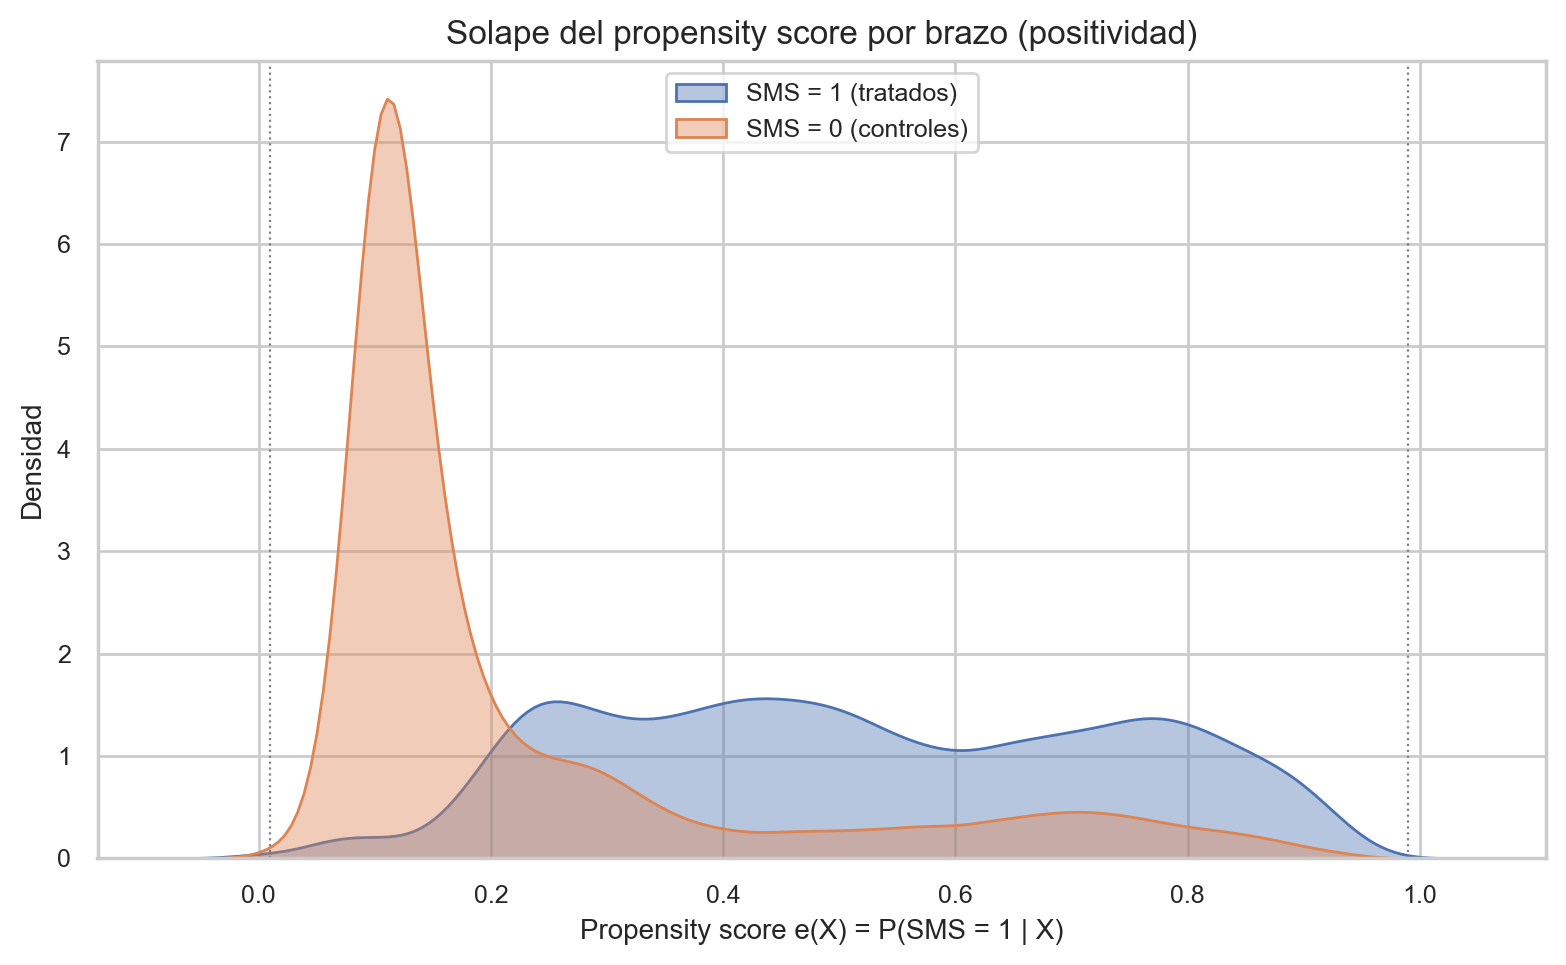

In [4]:
prop = causal.estimar_propensity_score(X, T, stats)
print(f"AUC del propensity (separación tratados/controles): {prop.auc:.4f}")
print("Distribución de e(X):")
for k, v in prop.diagnostico_distribucion.items():
    print(f"  {k}: {v:.4f}")

fig_overlap = rutas.FIGURAS / "nb04_overlap_propensidad_v1.png"
causal.plot_overlap_propensidad(prop.e_x, T, fig_overlap)
display(Image(str(fig_overlap), width=700))

**Lectura.** AUC = 0,849: la asignación del SMS es casi determinista en las covariables
— coherente con la regla operativa del sistema de origen (el SMS solo se enviaba a citas
con antelación suficiente, ver NB02 §4: r(lead_time, SMS) = 0,40). Las densidades de
e(X) muestran masa de controles cerca de 0 sin tratados equivalentes: **violación
estructural de positividad**, no escasez muestral.

## 4. Pesos IPW estabilizados y diagnósticos

Pesos estabilizados ω = P(T=1)/e(X) para tratados, P(T=0)/(1−e(X)) para controles.
Diagnósticos pre-especificados: distribución de pesos, **ESS por brazo** (regla de
trimming: ESS/n < 0,5 en cualquier brazo → especificación preferida = trimmed 1/99) y
balance por SMD (|SMD| < 0,10 = aceptable).

00:54:45 [INFO] ESS tratados=44 (0.1%); ESS controles=44290 (61.2%); trim=True.


/Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/src/causal.py:539: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.tight_layout()
/Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/src/causal.py:539: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.tight_layout()
/Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/src/causal.py:540: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Arial.
  fig.savefig(ruta_fig, dpi=DPI_FIGURAS, bbox_inches="tight")
/Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/src/causal.py:540: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.savefig(ruta_fig, dpi=DPI_FIGURAS, bbox_inches="tight")


[Pesos estabilizados]
  tratados: media=404.868, p99=4.056, max=323,264
  controles: media=1.068, p99=4.862, max=19

[ESS]
  tratados: ESS=44 (0.1% de n=34,585)
  controles: ESS=44,290 (61.2% de n=72,402)
  Regla ESS/n < 0.5 → trim recomendado: True


00:54:45 [INFO] Histograma de pesos guardado en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb04_distribucion_pesos_v1.png.


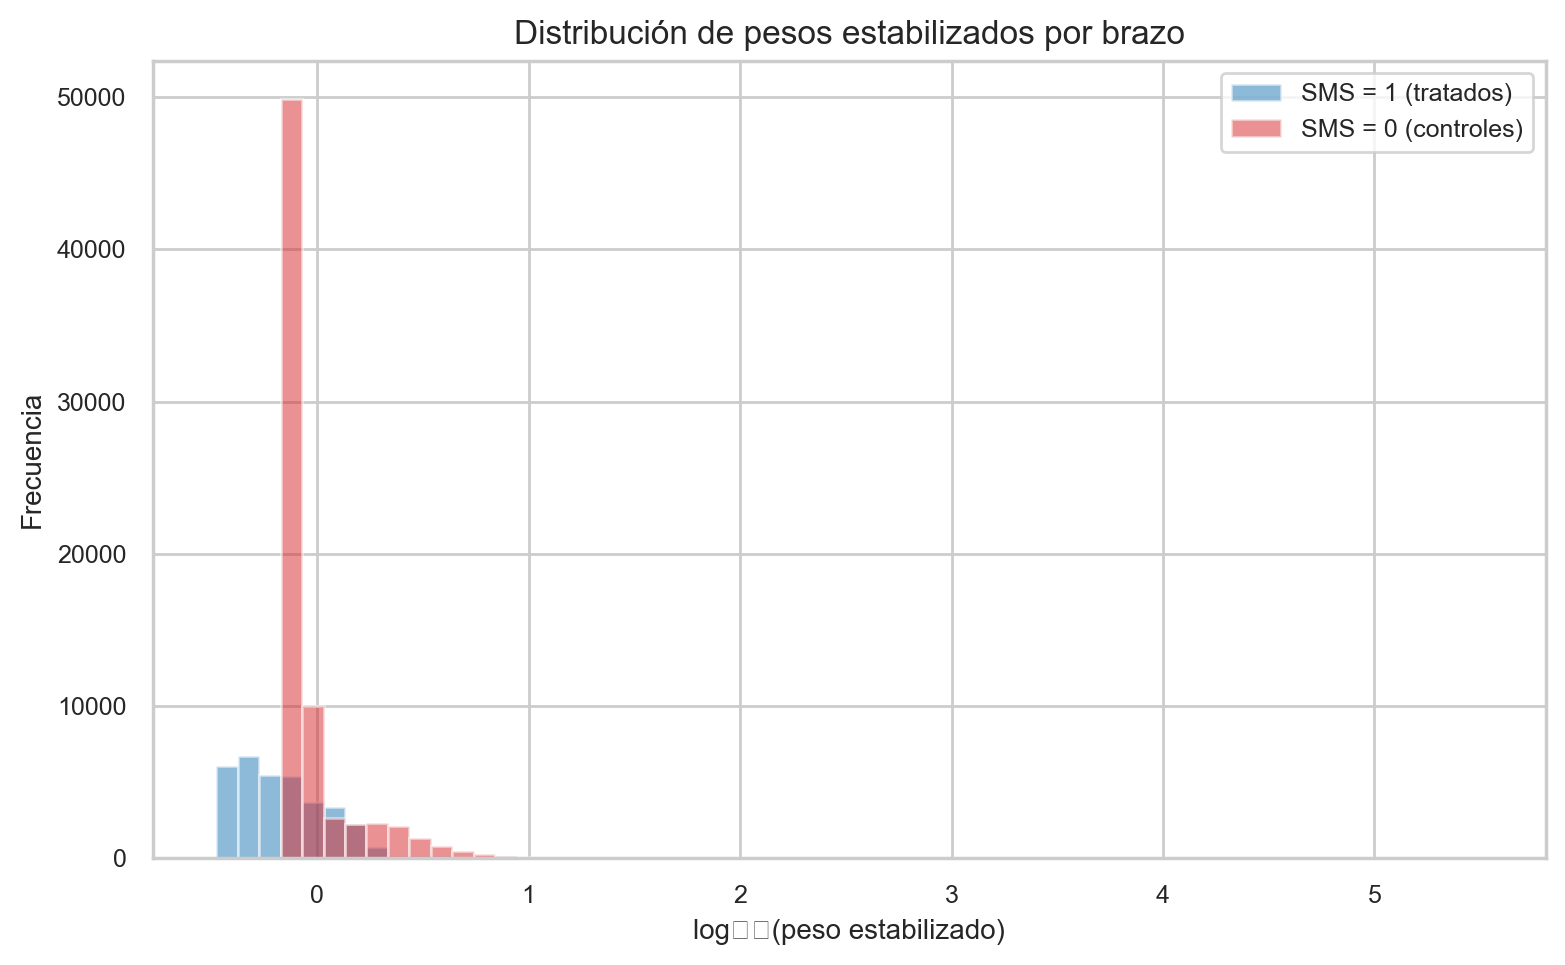

In [5]:
w = causal.pesos_estabilizados(prop.e_x, T, prop.p_tratamiento)
resumen_w = causal.resumen_pesos(w, T)
print("[Pesos estabilizados]")
for brazo, sw in resumen_w.items():
    print(f"  {brazo}: media={sw['media']:.3f}, p99={sw['p99']:.3f}, max={sw['max']:,.0f}")

ess = causal.calcular_ess(w, T)
print("\n[ESS]")
for brazo in ("tratados", "controles"):
    print(f"  {brazo}: ESS={ess[brazo]['ess']:,.0f} "
          f"({100 * ess[brazo]['ess_sobre_n']:.1f}% de n={ess[brazo]['n']:,})")
print(f"  Regla ESS/n < {causal.TRIM_ESS_UMBRAL} → trim recomendado: {ess['trim_recomendado']}")

fig_pesos = rutas.FIGURAS / "nb04_distribucion_pesos_v1.png"
causal.plot_distribucion_pesos(w, T, fig_pesos)
display(Image(str(fig_pesos), width=700))

00:54:45 [INFO] Balance post-ponderación: 1 / 21 covariables con |SMD| < 0.10.


Top 5 covariables peor balanceadas tras IPW:
              etiqueta   smd_pre  smd_post
     antelación (días)  0.871478  9.574264
      mes programación -0.631089  8.753684
      antelación² (z²)  0.201176  8.130150
          hipertensión -0.018872  1.531492
cualquier comorbilidad -0.050191  1.375480

Balance post-IPW: 1/21 covariables con |SMD| < 0,10; max |SMD| = 9.57


00:54:45 [INFO] Love plot guardado en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb04_love_plot_v1.png.


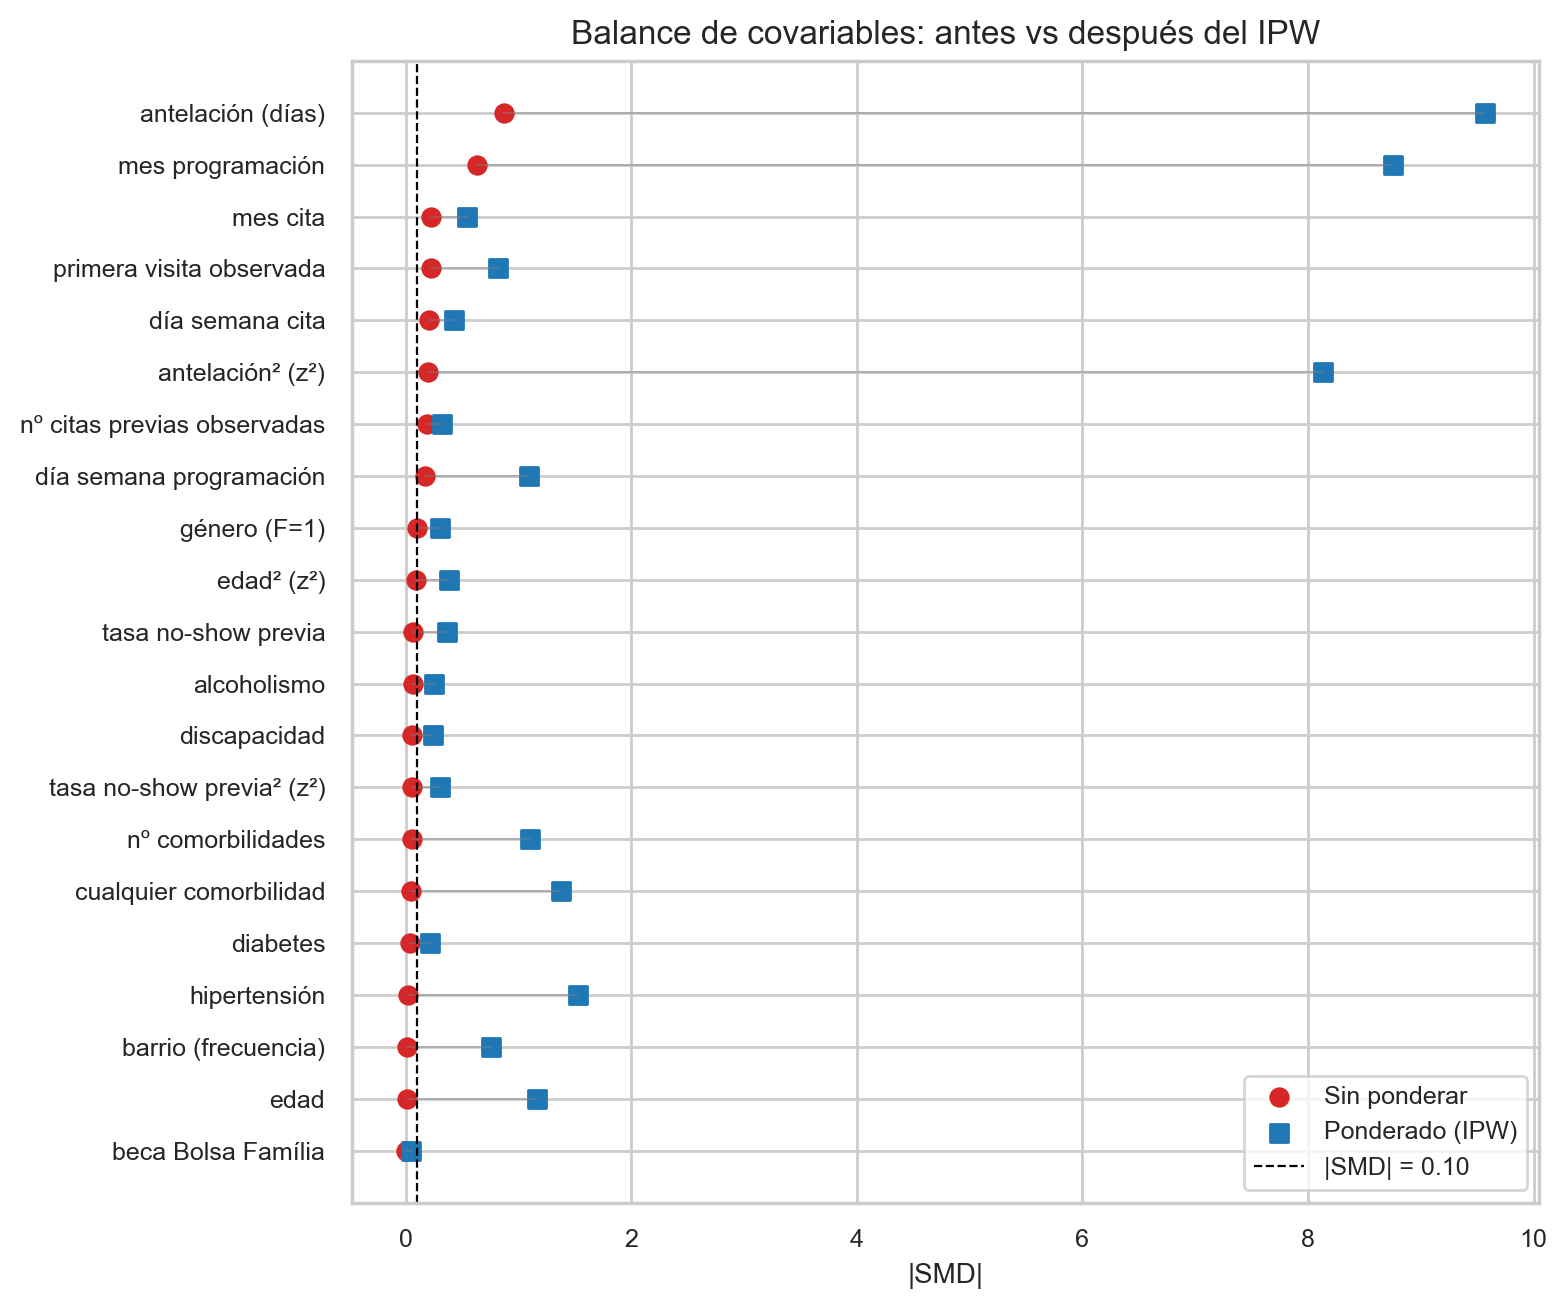

In [6]:
tabla_smd = causal.calcular_tabla_smd(X, T, w)
print("Top 5 covariables peor balanceadas tras IPW:")
print(tabla_smd[["etiqueta", "smd_pre", "smd_post"]].head(5).to_string(index=False))
n_bal = int((tabla_smd["abs_smd_post"] < 0.10).sum())
print(f"\nBalance post-IPW: {n_bal}/{len(tabla_smd)} covariables con |SMD| < 0,10; "
      f"max |SMD| = {tabla_smd['abs_smd_post'].max():.2f}")
tabla_smd.to_csv(rutas.REPORTES / "nb04_smd_tabla_v1.csv", index=False)

fig_love = rutas.FIGURAS / "nb04_love_plot_v1.png"
causal.plot_love(tabla_smd, fig_love)
display(Image(str(fig_love), width=700))

**Lectura.** El diagnóstico es inequívoco: ESS/n del brazo tratado = **0,1%** — unas
pocas decenas de tratados con e(X) ≈ 0 reciben pesos de hasta ~323.000 y concentran
todo el peso efectivo del brazo. El balance no se recupera (1/21 covariables con
|SMD| < 0,10; max |SMD| = 9,57 en la antelación). La ponderación IPW no está
funcionando: no hay soporte común que reponderar.

## 5. Tabla ATE y regla de trimming: el ATE no es identificable

Se reportan las tres especificaciones (untrimmed, trimmed 1/99, trimmed 5/95) como
panel de robustez. La regla pre-especificada selecciona trimmed 1/99 al haberse
disparado ESS/n < 0,5.

In [7]:
spec_pref = causal.decidir_especificacion_preferida(ess)
tabla_ate = causal.construir_tabla_ate(Y, T, w, spec_pref)
tabla_ate.to_csv(rutas.REPORTES / "nb04_ate_tabla_v1.csv", index=False)
print(tabla_ate.to_string(index=False))
sensibilidad_trim = tabla_ate["ate_pp"].max() - tabla_ate["ate_pp"].min()
print(f"\nSpec preferida por la regla: {spec_pref}")
print(f"Sensibilidad al trimming (max − min): {sensibilidad_trim:.2f} pp")

especificacion  pct_inferior  pct_superior  n_filas_usadas     ate_pp  es_preferida
     untrimmed           NaN           NaN          106987 -10.428055         False
  trimmed_1_99           1.0          99.0          104847  -5.767755          True
  trimmed_5_95           5.0          95.0           96287  -8.718805         False

Spec preferida por la regla: trimmed_1_99
Sensibilidad al trimming (max − min): 4.66 pp


**Lectura.** El ATE oscila entre −10,4 y −5,8 pp según el recorte: una sensibilidad de
~4,7 pp que multiplica varias veces cualquier efecto plausible del SMS. Junto con los
diagnósticos de §4, la conclusión es que **el ATE no es identificable con estos datos**:
no existe una población comparable completa sobre la que promediar. Nótese que los tres
ATE son fuertemente negativos — la ponderación no consigue eliminar la confusión por
indicación documentada en NB02 (el SMS se enviaba a citas de mayor riesgo basal).

## 6. Contingencia pre-especificada: estimand ATO (overlap weights)

La contingencia pre-especificada para este escenario: si ESS/n < 0,5, pasar a **overlap
weights** (Li, Morgan & Zaslavsky, 2018): ω = 1−e(X) para tratados, ω = e(X) para
controles. Propiedades: pesos acotados en [0, 1] (sin trimming arbitrario) y balance
exacto en media para toda covariable incluida en e(X).

**El estimand cambia**: el ATO es el efecto medio en la subpoblación con propensities
en zona de equipoise (cercanas a 0,5) — los pacientes para los que el envío del SMS era
genuinamente discrecional. No es el ATE ni el ATT, y no se extrapola fuera de esa
subpoblación.

00:54:45 [INFO] ESS tratados=28562 (82.6%); ESS controles=40179 (55.5%); trim=False.


00:54:45 [INFO] Balance post-ponderación: 21 / 21 covariables con |SMD| < 0.10.


[ESS bajo ATO]
  tratados: 82.6% de n=34,585
  controles: 55.5% de n=72,402
Peso máximo: IPW = 323,264  →  ATO = 1.0000 (acotado en [0, 1])

Balance post-ATO: 21/21 covariables con |SMD| < 0,10; max |SMD| = 0.0171


00:54:45 [INFO] Love plot guardado en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb04_love_plot_ato_v1.png.


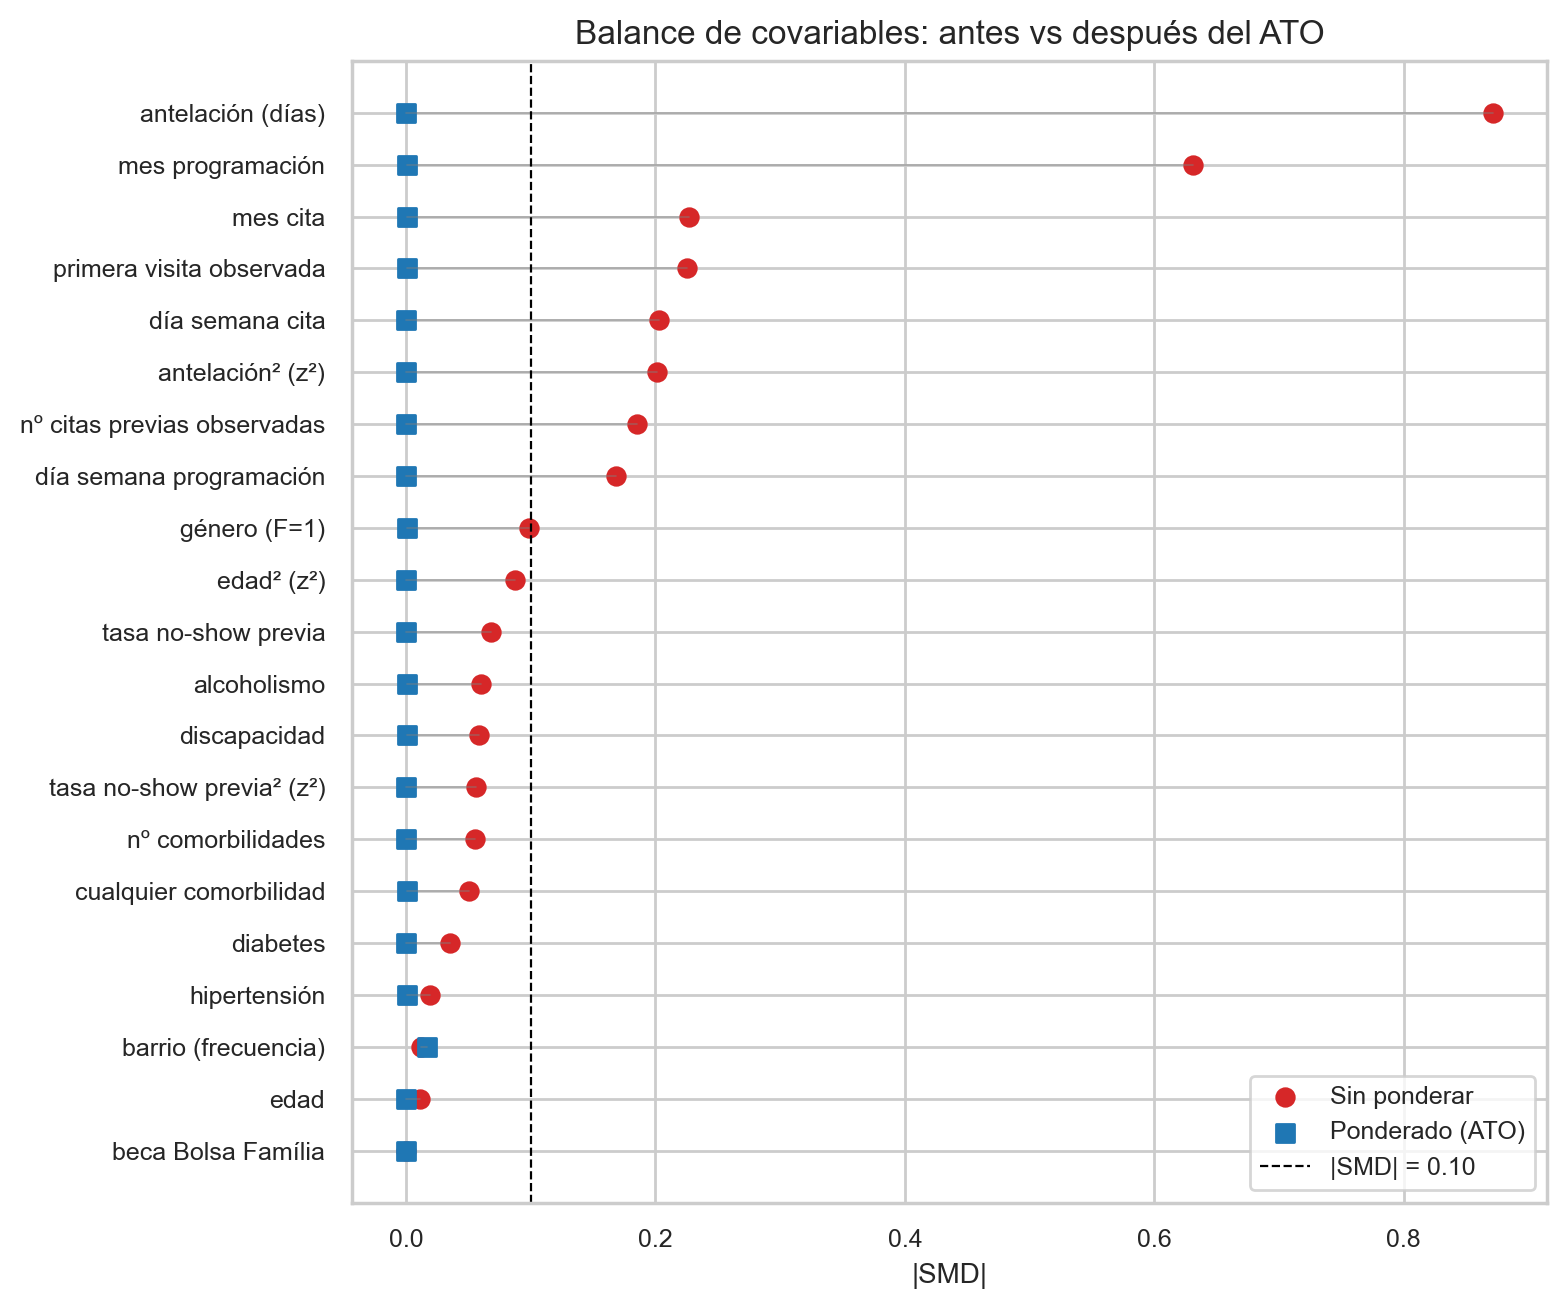

In [8]:
w_ato = causal.pesos_overlap_ato(prop.e_x, T)
ess_ato = causal.calcular_ess(w_ato, T)
print("[ESS bajo ATO]")
for brazo in ("tratados", "controles"):
    print(f"  {brazo}: {100 * ess_ato[brazo]['ess_sobre_n']:.1f}% de n={ess_ato[brazo]['n']:,}")
print(f"Peso máximo: IPW = {w.max():,.0f}  →  ATO = {w_ato.max():.4f} (acotado en [0, 1])")

tabla_smd_ato = causal.calcular_tabla_smd(X, T, w_ato)
n_bal_ato = int((tabla_smd_ato["abs_smd_post"] < 0.10).sum())
print(f"\nBalance post-ATO: {n_bal_ato}/{len(tabla_smd_ato)} covariables con |SMD| < 0,10; "
      f"max |SMD| = {tabla_smd_ato['abs_smd_post'].max():.4f}")
tabla_smd_ato.to_csv(rutas.REPORTES / "nb04_smd_ato_tabla_v1.csv", index=False)

fig_love_ato = rutas.FIGURAS / "nb04_love_plot_ato_v1.png"
causal.plot_love(tabla_smd_ato, fig_love_ato, metodo="ATO")
display(Image(str(fig_love_ato), width=700))

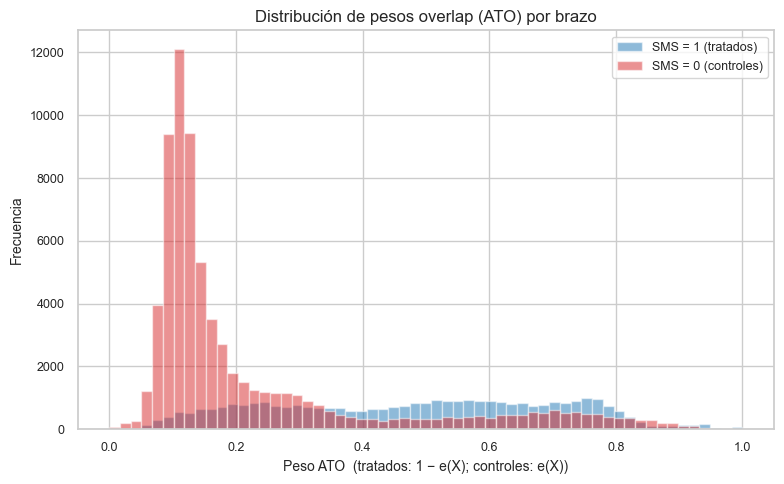

ATO puntual: -1.242 pp  (positivo = SMS asociado con mayor asistencia)


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
bins = np.linspace(0, 1, 60)
ax.hist(w_ato[T == 1], bins=bins, alpha=0.5, label="SMS = 1 (tratados)", color="#1f77b4")
ax.hist(w_ato[T == 0], bins=bins, alpha=0.5, label="SMS = 0 (controles)", color="#d62728")
ax.set_xlabel("Peso ATO  (tratados: 1 − e(X); controles: e(X))")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de pesos overlap (ATO) por brazo")
ax.legend()
fig.tight_layout()
fig.savefig(rutas.FIGURAS / "nb04_distribucion_pesos_ato_v1.png",
            dpi=causal.DPI_FIGURAS, bbox_inches="tight")
plt.show()

ato_punto = causal.ate_ato(Y, T, prop.e_x)
print(f"ATO puntual: {ato_punto:+.3f} pp  (positivo = SMS asociado con mayor asistencia)")

## 7. Incertidumbre: cluster bootstrap por PatientId

Los pacientes se repiten en el dataset, así que el bootstrap por filas subestimaría la
varianza. Se remuestrean **PatientIds completos** con reemplazo (1.000 iteraciones,
semilla fija) y en cada iteración se refita la logística sobre el remuestreo (la base
cuadrática queda congelada). IC95% por percentiles.

00:54:46 [INFO] Histograma del bootstrap guardado en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb04_bootstrap_ato_distribucion_v1.png.


Bootstrap cargado de nb04_bootstrap_ato_v1.npy (1000 iteraciones).
ATO bootstrap: media = -1.243 pp; IC95% = [-1.922, -0.511] pp; sd = 0.363
IC95% cruza cero: False


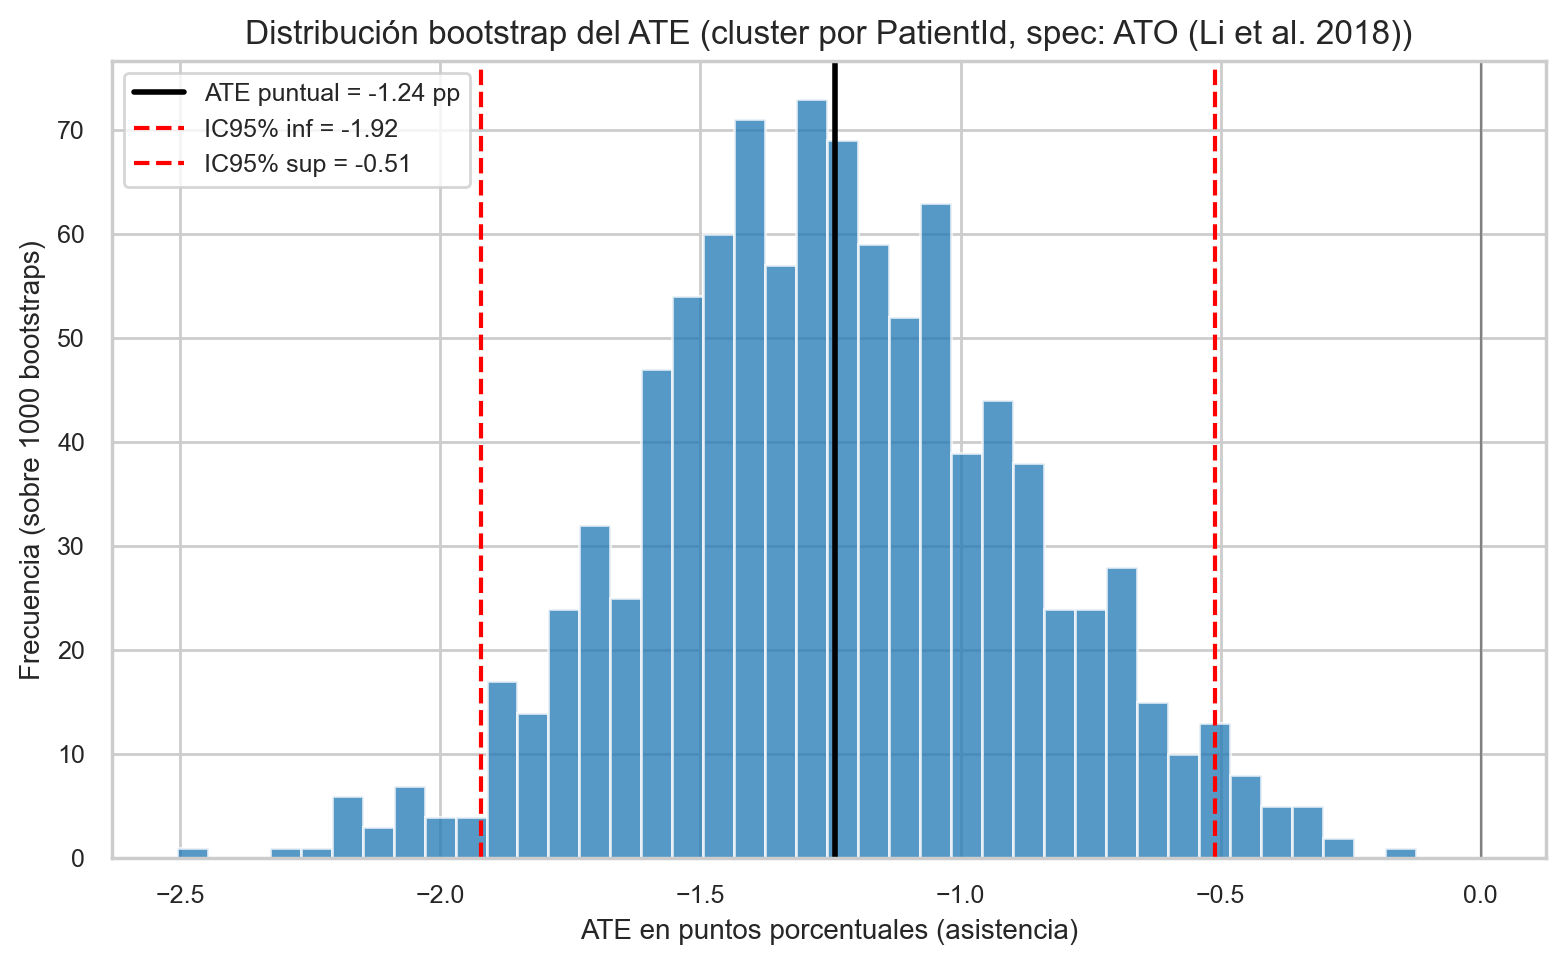

In [10]:
ruta_boot = rutas.BOOTSTRAP / "nb04_bootstrap_ato_v1.npy"
if REGENERAR_BOOTSTRAP or not ruta_boot.exists():
    atos = causal.cluster_bootstrap_ato(X=X, T=T, Y=Y,
                                        patient_ids=df[causal.COL_CLUSTER],
                                        n_iter=causal.N_BOOTSTRAP,
                                        seed=causal.SEED_BOOTSTRAP)
    causal.persistir_bootstrap(atos, ruta_boot)
else:
    atos = np.load(ruta_boot)
    print(f"Bootstrap cargado de {ruta_boot.name} ({len(atos)} iteraciones).")

res_boot = causal.resumen_bootstrap(atos)
print(f"ATO bootstrap: media = {res_boot['media']:+.3f} pp; "
      f"IC95% = [{res_boot['ic95_inf']:+.3f}, {res_boot['ic95_sup']:+.3f}] pp; "
      f"sd = {res_boot['sd']:.3f}")
print(f"IC95% cruza cero: {res_boot['ic95_inf'] < 0 < res_boot['ic95_sup']}")

fig_boot = rutas.FIGURAS / "nb04_bootstrap_ato_distribucion_v1.png"
causal.plot_distribucion_ate_bootstrap(atos, ato_punto, fig_boot, spec="ATO (Li et al. 2018)")
display(Image(str(fig_boot), width=700))

**Lectura.** ATO = −1,24 pp, IC95% [−1,92, −0,51]: el intervalo excluye el cero con
signo negativo — bajo esta especificación, el SMS estaría asociado con *menor*
asistencia en la subpoblación de solapamiento. Antes de interpretarlo, hay que someterlo
al análisis de sensibilidad pre-especificado (§8): la forma funcional de la antelación
es la decisión de modelado con más carga de todo el propensity.

## 8. Sensibilidad a la especificación de la antelación: el resultado no es robusto

Si la regla operativa de envío era un umbral en días, los términos z + z² podrían
suavizarla artificialmente. Especificación alternativa: `lead_time` en 5 bins
operacionalmente plausibles ({0, 1–3, 4–7, 8–30, >30} días). Regla pre-especificada de
robustez: **misma dirección del efecto + solapamiento de los IC95%**.

In [11]:
X_cat, T_cat, Y_cat, stats_cat = causal.construir_matriz_propensidad(
    df, lead_time_spec="categorical")
prop_cat = causal.estimar_propensity_score(X_cat, T_cat, stats_cat)
print(f"AUC propensity (spec categórica): {prop_cat.auc:.4f}")

w_cat = causal.pesos_overlap_ato(prop_cat.e_x, T_cat)
tabla_smd_cat = causal.calcular_tabla_smd(X_cat, T_cat, w_cat)
print(f"Balance post-ATO (categórica): "
      f"{int((tabla_smd_cat['abs_smd_post'] < 0.10).sum())}/{len(tabla_smd_cat)} "
      f"con |SMD| < 0,10; max |SMD| = {tabla_smd_cat['abs_smd_post'].max():.4f}")

ato_cat = causal.ate_ato(Y_cat, T_cat, prop_cat.e_x)
print(f"ATO (spec categórica): {ato_cat:+.3f} pp")

ruta_boot_cat = rutas.BOOTSTRAP / "nb04_bootstrap_ato_leadcat_v1.npy"
if REGENERAR_BOOTSTRAP or not ruta_boot_cat.exists():
    atos_cat = causal.cluster_bootstrap_ato(X=X_cat, T=T_cat, Y=Y_cat,
                                            patient_ids=df[causal.COL_CLUSTER],
                                            n_iter=causal.N_BOOTSTRAP,
                                            seed=causal.SEED_BOOTSTRAP)
    np.save(ruta_boot_cat, atos_cat)
else:
    atos_cat = np.load(ruta_boot_cat)
    print(f"Bootstrap categórico cargado ({len(atos_cat)} iteraciones).")

res_cat = causal.resumen_bootstrap(atos_cat)
print(f"IC95% (categórica): [{res_cat['ic95_inf']:+.3f}, {res_cat['ic95_sup']:+.3f}] pp")

00:54:46 [INFO] Matriz de propensidad construida (lead_time_spec=categorical): X.shape=(106987, 23), 34585 tratados, 72402 controles.


00:54:46 [INFO] Propensity ajustada: AUC=0.888, P(T=1)=0.323, e(X) ∈ [0.000, 0.948]; 34.73% con e<0.01, 0.00% con e>0.99.


00:54:46 [INFO] Balance post-ponderación: 23 / 23 covariables con |SMD| < 0.10.


AUC propensity (spec categórica): 0.8883
Balance post-ATO (categórica): 23/23 con |SMD| < 0,10; max |SMD| = 0.0124
ATO (spec categórica): +5.402 pp
Bootstrap categórico cargado (1000 iteraciones).
IC95% (categórica): [+4.639, +6.207] pp


Misma dirección: False  |  IC95% se solapan: False
→ Regla pre-especificada de robustez: NO ROBUSTO


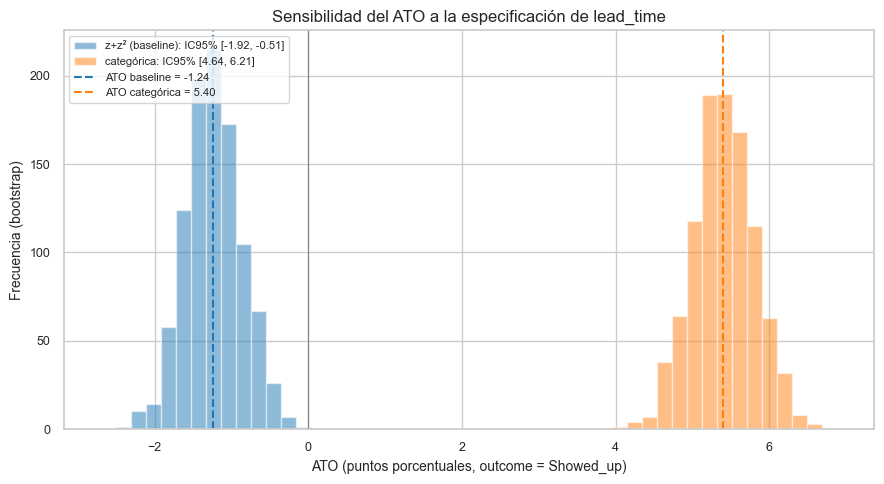

In [12]:
def ic95_se_solapan(a_lo, a_hi, b_lo, b_hi):
    return max(a_lo, b_lo) <= min(a_hi, b_hi)

misma_direccion = (res_boot["media"] * res_cat["media"]) > 0
solapan = ic95_se_solapan(res_boot["ic95_inf"], res_boot["ic95_sup"],
                          res_cat["ic95_inf"], res_cat["ic95_sup"])
robusto = misma_direccion and solapan
print(f"Misma dirección: {misma_direccion}  |  IC95% se solapan: {solapan}")
print(f"→ Regla pre-especificada de robustez: {'ROBUSTO' if robusto else 'NO ROBUSTO'}")

fig, ax = plt.subplots(figsize=(9, 5))
bins_hist = np.linspace(min(atos.min(), atos_cat.min()) - 0.2,
                        max(atos.max(), atos_cat.max()) + 0.2, 50)
ax.hist(atos, bins=bins_hist, alpha=0.5, color="#1f77b4", edgecolor="white",
        label=f"z+z² (baseline): IC95% [{res_boot['ic95_inf']:.2f}, {res_boot['ic95_sup']:.2f}]")
ax.hist(atos_cat, bins=bins_hist, alpha=0.5, color="#ff7f0e", edgecolor="white",
        label=f"categórica: IC95% [{res_cat['ic95_inf']:.2f}, {res_cat['ic95_sup']:.2f}]")
ax.axvline(0, color="gray", lw=0.8)
ax.axvline(ato_punto, color="#1f77b4", ls="--", lw=1.5,
           label=f"ATO baseline = {ato_punto:.2f}")
ax.axvline(ato_cat, color="#ff7f0e", ls="--", lw=1.5,
           label=f"ATO categórica = {ato_cat:.2f}")
ax.set_xlabel("ATO (puntos porcentuales, outcome = Showed_up)")
ax.set_ylabel("Frecuencia (bootstrap)")
ax.set_title("Sensibilidad del ATO a la especificación de lead_time")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(rutas.FIGURAS / "nb04_sensibilidad_lead_v1.png",
            dpi=causal.DPI_FIGURAS, bbox_inches="tight")
plt.show()

**Lectura.** Las dos especificaciones — ambas con balance exacto y diagnósticos
impecables bajo ATO — producen efectos de **signo opuesto con IC95% disjuntos**
(−1,24 pp vs +5,40 pp). La regla pre-especificada dictamina NO ROBUSTO. La
interpretación honesta: dentro de la zona de solapamiento, el efecto estimado depende
por completo de cómo se modele la antelación — exactamente la variable que gobernaba la
asignación cuasi-determinista del SMS. **La evidencia observacional disponible no
permite una estimación estable del efecto del SMS**, ni siquiera restringida a la
subpoblación de equipoise.

## 9. E-value (sensibilidad a confusión no observada)

Se reporta como diagnóstico secundario sobre la spec baseline, con dos cautelas: la
conversión pp → RR es aproximada, y el E-value pierde relevancia cuando el propio signo
del efecto no es robusto a la especificación (§8).

In [13]:
rr, asis_T, asis_C = causal.ate_pp_a_rr(ato_punto, Y, T, w_ato)
ev = causal.evalue(rr)
print(f"Asistencia ponderada (ATO): SMS=1 → {100 * asis_T:.2f}%  |  SMS=0 → {100 * asis_C:.2f}%")
print(f"RR aproximado = {rr:.4f}  →  E-value = {ev:.3f}")
print("Lectura: bastaría una confusión no observada de magnitud modesta para explicar "
      "el efecto baseline — coherente con la fragilidad documentada en §8.")

Asistencia ponderada (ATO): SMS=1 → 73.34%  |  SMS=0 → 74.59%
RR aproximado = 0.9834  →  E-value = 1.148
Lectura: bastaría una confusión no observada de magnitud modesta para explicar el efecto baseline — coherente con la fragilidad documentada en §8.


## 10. Persistencia y decisión para el modelo económico (NB06)

**Decisión metodológica:** el Monte Carlo de NB06 **no consume** la distribución
bootstrap de este notebook. Dado el veredicto de no-robustez, el parámetro de efecto se
modela mediante escenarios de **reducción relativa del no-show informados por la
evidencia experimental publicada** (Gurol-Urganci et al., 2013; Robotham et al., 2016).
El resultado de este notebook se reporta en la memoria como evidencia de
no-identificabilidad observacional: ni 107k registros bastan cuando la asignación del
tratamiento es cuasi-determinista en una covariable.

Artefactos persistidos para los notebooks siguientes y la memoria.

In [14]:
causal.persistir_propensidad(prop, rutas.MODELOS / "propensidad_v1.pkl")

pesos_df = pd.DataFrame({
    "PatientId": df[causal.COL_CLUSTER].to_numpy(),
    "AppointmentID": df["AppointmentID"].to_numpy(),
    "SMS_received": T,
    "Showed_up": df[causal.COL_OUTCOME].to_numpy(),
    "propensity_score": prop.e_x,
    "peso_estabilizado": w,
    "peso_ato": w_ato,
})
ruta_pesos = rutas.REPORTES / "nb04_pesos_propension_v1.csv"
pesos_df.to_csv(ruta_pesos, index=False)
print(f"Pesos por fila → {ruta_pesos.name} ({len(pesos_df):,} filas)  [entrada de NB05]")

sidecar = {
    "notebook": "04_inferencia_causal_ipw",
    "estimand_resultante": "ATO (Li, Morgan & Zaslavsky 2018) — contingencia pre-especificada",
    "propensity_auc": float(prop.auc),
    "ess_ipw_sobre_n": {b: float(ess[b]["ess_sobre_n"]) for b in ("tratados", "controles")},
    "trim_disparado": bool(ess["trim_recomendado"]),
    "tabla_ate_ipw": tabla_ate.to_dict(orient="records"),
    "ato_punto_pp": float(ato_punto),
    "ato_ic95": [float(res_boot["ic95_inf"]), float(res_boot["ic95_sup"])],
    "ato_categorico_pp": float(ato_cat),
    "ato_categorico_ic95": [float(res_cat["ic95_inf"]), float(res_cat["ic95_sup"])],
    "robusto_a_spec_lead_time": bool(robusto),
    "e_value_ato_baseline": float(ev),
    "decision_nb06": ("El Monte Carlo de NB06 no consume este bootstrap: el efecto se "
                      "parametriza con escenarios de reducción relativa del no-show de la "
                      "literatura experimental publicada. El ATO se reporta como evidencia "
                      "de no-identificabilidad observacional."),
}
causal.persistir_sidecar(sidecar, rutas.REPORTES / "nb04_metadatos_v1.json")

00:54:46 [INFO] Propensidad persistida en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/modelos/propensidad_v1.pkl.


00:54:46 [INFO] Sidecar JSON guardado en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/reportes/nb04_metadatos_v1.json.


Pesos por fila → nb04_pesos_propension_v1.csv (106,987 filas)  [entrada de NB05]


## 11. Conclusiones

1. La asignación del SMS es cuasi-determinista en la antelación (AUC propensity 0,849):
   **violación estructural de positividad**. El IPW estabilizado no es viable (ESS/n
   tratados 0,1%; balance fallido; ATE inestable al trimming). El ATE no es
   identificable con estos datos.
2. La contingencia pre-especificada (ATO) restaura los diagnósticos (balance exacto,
   ESS sano, pesos acotados), pero el efecto estimado **no es robusto** a la
   especificación de la antelación: −1,24 pp [−1,92, −0,51] vs +5,40 pp [+4,64, +6,21].
3. Conclusión para la memoria (lenguaje asociacional, no causal): *la evidencia
   observacional disponible no permite una estimación estable de la asociación entre el
   SMS y la asistencia; el signo del ATO depende de la especificación de la antelación.*
4. El valor metodológico del capítulo no es el número, sino el proceso: reglas de
   diagnóstico y contingencia pre-especificadas que detectaron el problema y limitaron
   la tentación de elegir la especificación conveniente.

In [15]:
# Verificación final de reglas críticas del proyecto
assert causal.COL_TRATAMIENTO not in X.columns, "el tratamiento no puede ser covariable"
assert "neighbourhood_encoded" in X.columns, "barrio debe ir con frequency encoding"
assert len(df) > 100_000, "el análisis causal usa el dataset completo, no el train split"
assert not robusto, "si esto falla, la narrativa de §8 y la memoria deben revisarse"
print("Checklist de reglas críticas: OK")
print("NB04 completo.")

Checklist de reglas críticas: OK
NB04 completo.
